<a href="https://colab.research.google.com/github/vasudhabobde/Machine_Learning_Practicals/blob/main/B3_B2_32_MLDSPractical_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("diabetes_dataset.csv")
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


1.Load the diabetes.csv dataset. Display head(), shape, all column names. Display target class distribution (yes/no) using count plot.

In [ ]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
df.describe

<bound method NDFrame.describe of      Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35        0  33.6   
1              1       85             66             29        0  26.6   
2              8      183             64              0        0  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27        0  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60              0        0  30.1   
767            1       93             70             31        0  30.4   

     DiabetesPedigreeFunction  Age  Outcome  
0                       0.627   50        1  
1                       0.351   31        0  
2                       0.672   32        1  
3                       0.167   21        0  
4                       2.288   33        1  
..                        ...  ...      ...  
763                     0.171   63        0  
764                     0.340   27        0  
765                     0.245   30        0  
766                     0.349   47        1  
767                     0.315   23        0  

[768 rows x 9 columns]>

In [ ]:
df.shape

(768, 9)

In [ ]:
df["Outcome"] = df["Outcome"].map({0: "No", 1: "Yes"})

In [ ]:
df.columns.tolist()

['Pregnancies',
 'Glucose',
 'BloodPressure',
 'SkinThickness',
 'Insulin',
 'BMI',
 'DiabetesPedigreeFunction',
 'Age',
 'Outcome']

In [ ]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [ ]:
print(df["Outcome"].value_counts())

Outcome
No     500
Yes    268
Name: count, dtype: int64


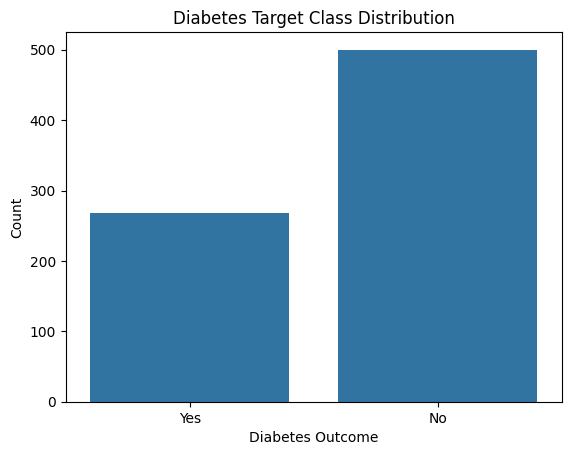

In [ ]:
sns.countplot(x="Outcome", data=df)
plt.title("Diabetes Target Class Distribution")
plt.xlabel("Diabetes Outcome")
plt.ylabel("Count")
plt.show()

2.Replace biologically invalid zero values in Glucose, BloodPressure, BMI, Insulin, and SkinThickness with their column medians.

In [ ]:
columns = ["Glucose","BloodPressure","BMI","Insulin","SkinThickness"]
for col in columns:
    median_value = df[col].median()
    df[col] = df[col].replace(0, median_value)

In [ ]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,30.5,33.6,0.627,50,Yes
1,1,85,66,29,30.5,26.6,0.351,31,No
2,8,183,64,23,30.5,23.3,0.672,32,Yes
3,1,89,66,23,94.0,28.1,0.167,21,No
4,0,137,40,35,168.0,43.1,2.288,33,Yes
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180.0,32.9,0.171,63,No
764,2,122,70,27,30.5,36.8,0.340,27,No
765,5,121,72,23,112.0,26.2,0.245,30,No
766,1,126,60,23,30.5,30.1,0.349,47,Yes


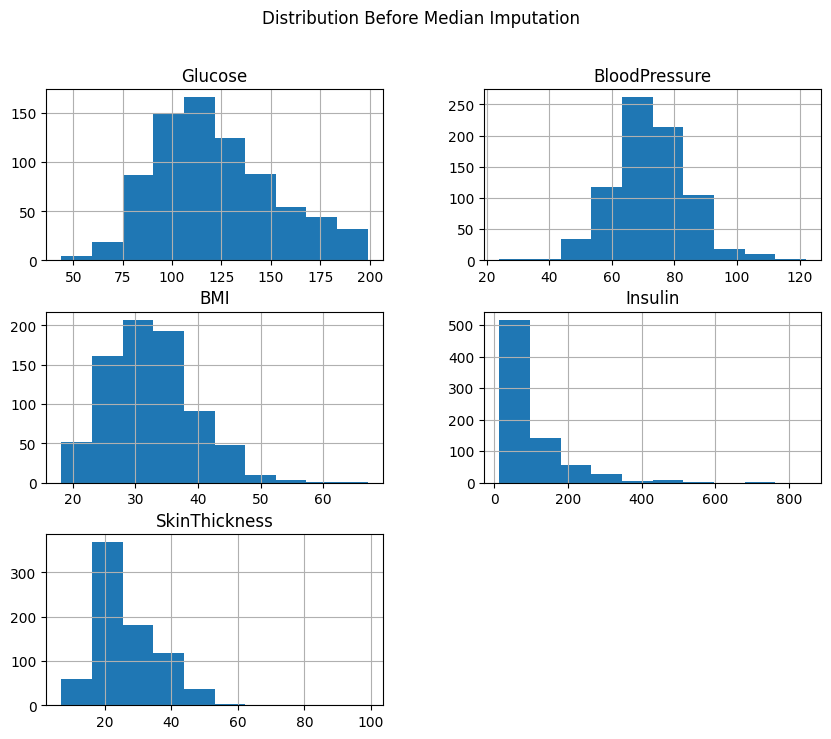

In [ ]:
#Before
import matplotlib.pyplot as plt
columns = ["Glucose", "BloodPressure", "BMI", "Insulin", "SkinThickness"]
df[columns].hist(figsize=(10, 8))
plt.suptitle("Distribution Before Median Imputation")
plt.show()

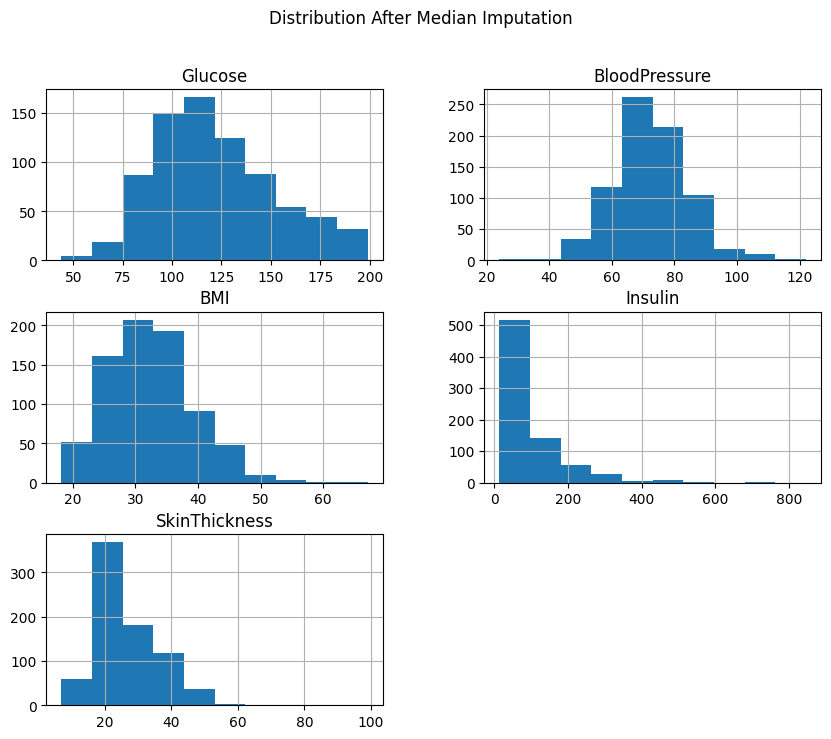

In [ ]:
#After
for col in columns:
    df[col] = df[col].replace(0, df[col].median())
df[columns].hist(figsize=(10, 8))
plt.suptitle("Distribution After Median Imputation")
plt.show()

3.Visualize feature distributions before and after zero-value treatment using side-by-side histograms for the affected columns.

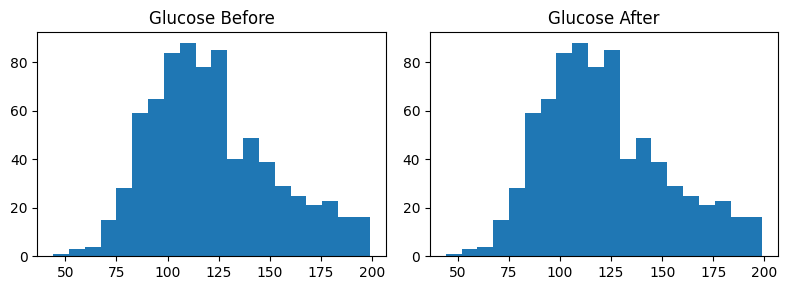

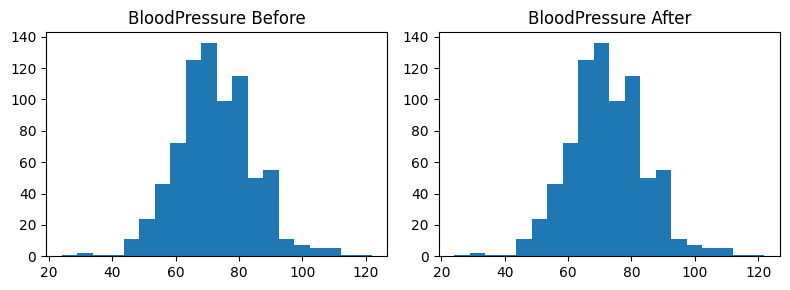

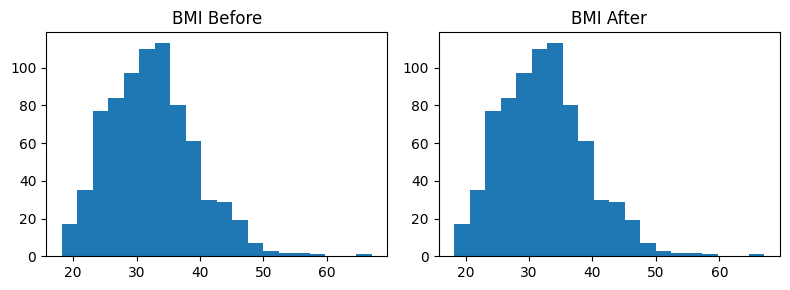

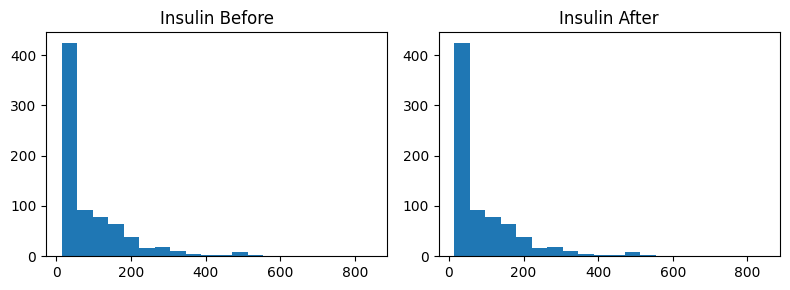

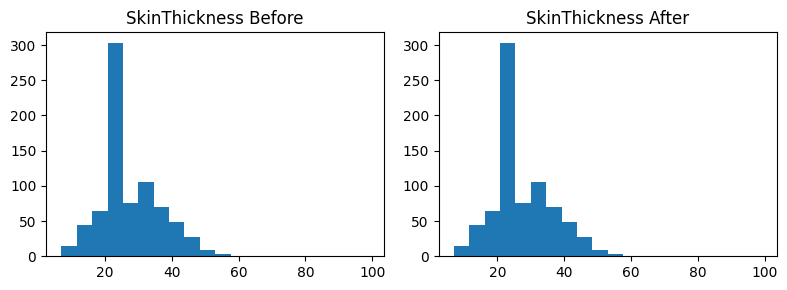

In [ ]:
import matplotlib.pyplot as plt
columns = ["Glucose", "BloodPressure", "BMI", "Insulin", "SkinThickness"]
# Before
before = df[columns].copy()

# Replace 0 with median
for col in columns:
    df[col] = df[col].replace(0, df[col].median())

# Side-by-side
for col in columns:
    plt.figure(figsize=(8, 3))

    plt.subplot(1, 2, 1)
    plt.hist(before[col], bins=20)
    plt.title(col + " Before")

    plt.subplot(1, 2, 2)
    plt.hist(df[col], bins=20)
    plt.title(col + " After")

    plt.tight_layout()
    plt.show()

4. Apply StandardScaler on all 8 features. Split data (75:25).

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)
print("\nTraining data:", X_train.shape)
print("Testing data:", X_test.shape)


Training data: (576, 8)
Testing data: (192, 8)


5.Train Logistic Regression (C=1, max_iter=1000). Print accuracy, precision, recall, F1-score

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

model = LogisticRegression(C=1, max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Logistic Regression Results:")
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, pos_label="Yes"))
print("Recall   :", recall_score(y_test, y_pred, pos_label="Yes"))
print("F1-score :", f1_score(y_test, y_pred, pos_label="Yes"))

Logistic Regression Results:
Accuracy : 0.734375
Precision: 0.6363636363636364
Recall   : 0.6086956521739131
F1-score : 0.6222222222222222


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
print("KNN Predictions:")
print(y_pred)

KNN Predictions:
[1 0 0 0 1 0 0 0 1 0 0 1 0 0 0 1 1 0 0 0 0 0 0 1 1 0 0 0 1 1 0 0 0 0 1 0 0
 0 0 0 1 0 0 0 1 0 1 0 1 1 0 0 0 0 0 1 1 0 0 0 1 1 1 0 0 1 0 0 0 0 0 1 1 0
 0 0 0 0 0 0 0 1 0 0 1 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 1 0 0 1 1 0 1 0 1 0
 0 0 1 1 0 1 0 0 1 1 1 0 0 0 0 0 1 0 0 1 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0
 1 0 0 1 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 1 0 0 0 1 0 1 0 1 0 0 1 1 0
 1 1 0 0 0 1 0]


In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.734375

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.83      0.80       125
           1       0.64      0.55      0.59        67

    accuracy                           0.73       192
   macro avg       0.71      0.69      0.70       192
weighted avg       0.73      0.73      0.73       192


Confusion Matrix:
[[104  21]
 [ 30  37]]


In [ ]:
#Naive Bayes
import pandas as pd
import numpy as np

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)


In [ ]:
df = pd.read_csv("diabetes_dataset.csv")

In [ ]:
print(df.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [ ]:
columns = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

for col in columns:
    df[col] = df[col].replace(0, np.nan)
    df[col] = df[col].fillna(df[col].median())

X = df.drop("Outcome", axis=1)
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [ ]:
model = GaussianNB()
model.fit(X_train, y_train)

GaussianNB()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.7239583333333334
Precision: 0.6
Recall: 0.6268656716417911
F1 Score: 0.6131386861313869


In [ ]:
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Confusion Matrix:
[[97 28]
 [25 42]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.78      0.79       125
           1       0.60      0.63      0.61        67

    accuracy                           0.72       192
   macro avg       0.70      0.70      0.70       192
weighted avg       0.73      0.72      0.73       192



8. Build a final comparison table (3 models × 5 metrics: accuracy, precision, recall, F1). Recommend the best model for clinical deployment with justification.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# 1. Logistic Regression
logistic_model = LogisticRegression(max_iter=1000)
logistic_model.fit(X_train, y_train)

# 2. KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# 3. Naive Bayes
nb = GaussianNB()
nb.fit(X_train, y_train)

print("All 3 models trained successfully!")

All 3 models trained successfully!


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# Predictions
y_pred_lr = logistic_model.predict(X_test)
y_pred_knn = knn.predict(X_test)
y_pred_nb = nb.predict(X_test)

# Comparison table
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "KNN", "Naive Bayes"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_nb)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_knn),
        precision_score(y_test, y_pred_nb)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_knn),
        recall_score(y_test, y_pred_nb)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_knn),
        f1_score(y_test, y_pred_nb)
    ]
})

print(comparison.round(3))

                 Model  Accuracy  Precision  Recall  F1 Score
0  Logistic Regression     0.729      0.636   0.522     0.574
1                  KNN     0.734      0.638   0.552     0.592
2          Naive Bayes     0.724      0.600   0.627     0.613
